## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

from neuro_fuzzy_toolbox import h_ANFIS, Hybrid_learning_algorithm, alt_SONFIS, EarlyStopping, get_measures, Gaussian_MF

In [2]:
import numpy as np

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Surface (10k)

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [5]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [6]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 32, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

## Model & Training

### ANFIS

In [7]:
model = h_ANFIS(
    input_size = 2,
    num_mfs = 1,
    outputs = 1,
    rule_reduced= True
)

In [8]:
model.init_premises(x_train)

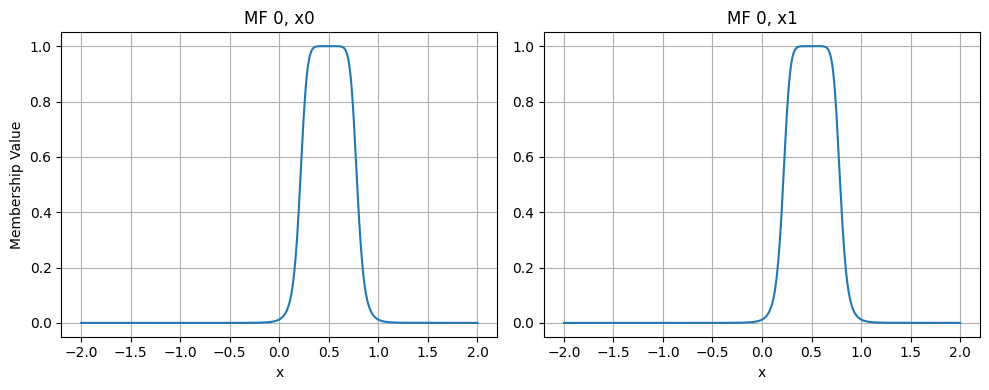

In [9]:
model.plot_premises()

### Hybrid Learning Algorithm

In [10]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [11]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [12]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=4)
last_training_iteration = True

In [13]:
sonfis = alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [14]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 6.103399 - validation loss: 6.427104
 -> ANFIS rules: 2

Iteration:  1/40 - loss: 2.928281 - validation loss: 3.129783
 -> ANFIS rules: 4

Iteration:  2/40 - loss: 1.568230 - validation loss: 1.640828
 -> ANFIS rules: 7

Iteration:  3/40 - loss: 1.356199 - validation loss: 1.404283
 -> ANFIS rules: 10

Iteration:  4/40 - loss: 1.091582 - validation loss: 1.168459
 -> ANFIS rules: 13

Iteration:  5/40 - loss: 1.067099 - validation loss: 1.141294
 -> ANFIS rules: 14

Iteration:  6/40 - loss: 0.483701 - validation loss: 0.498601
 -> ANFIS rules: 15

Iteration:  7/40 - loss: 0.455892 - validation loss: 0.485811
 -> ANFIS rules: 13

Iteration:  8/40 - loss: 0.593644 - validation loss: 0.596874
 -> ANFIS rules: 13

Iteration:  9/40 - loss: 0.490677 - validation loss: 0.507478
 -> ANFIS rules: 14

Iteration: 10/40 - loss: 0.644513 - validation loss: 0.660154
 -> ANFIS rules: 15

Early stopping

Training finished
 -> ANFIS rules: 15

CPU times: user 3min, sys: 4.4 s, t

In [15]:
test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.02334997922320066
RMSE: 0.15280699991558194
MAE: 0.10823625090458282
R2: 0.9936068137237389
MAPE: 21.5397783580031


In [16]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.032362550046789555
RMSE: 0.17989594227438693
MAE: 0.1369653970214823
R2: 0.9910563862397792
MAPE: 2.2913195851623964


# Surface (1k)

## Data

In [17]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.1,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [18]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [19]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), batch_size = 16, shuffle = True)
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [21]:
model = h_ANFIS(
    input_size = 2,
    num_mfs = 1,
    outputs = 1,
    rule_reduced = True
)

In [22]:
model.init_premises(x_train)

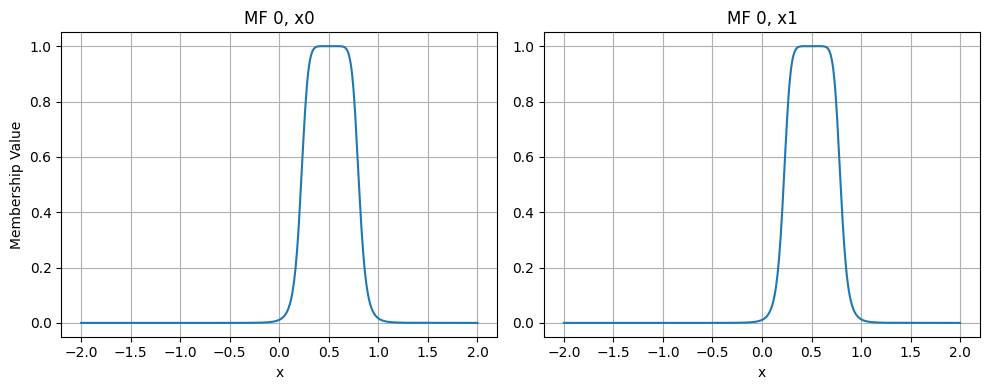

In [23]:
model.plot_premises()

### Hybrid Learning Algorithm

In [24]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [25]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [26]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [27]:
sonfis = alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [28]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 6.197824 - validation loss: 6.661412
 -> ANFIS rules: 2

Iteration:  1/40 - loss: 1.656372 - validation loss: 2.045438
 -> ANFIS rules: 3

Iteration:  2/40 - loss: 1.143934 - validation loss: 1.191777
 -> ANFIS rules: 4

Iteration:  3/40 - loss: 1.088238 - validation loss: 1.113061
 -> ANFIS rules: 4

Iteration:  4/40 - loss: 0.668321 - validation loss: 0.775602
 -> ANFIS rules: 4

Iteration:  5/40 - loss: 0.528340 - validation loss: 0.608694
 -> ANFIS rules: 4

Iteration:  6/40 - loss: 0.792061 - validation loss: 0.898986
 -> ANFIS rules: 4

Iteration:  7/40 - loss: 0.429317 - validation loss: 0.517367
 -> ANFIS rules: 5

Iteration:  8/40 - loss: 0.358143 - validation loss: 0.445698
 -> ANFIS rules: 5

Iteration:  9/40 - loss: 0.318218 - validation loss: 0.338260
 -> ANFIS rules: 4

Iteration: 10/40 - loss: 1.086804 - validation loss: 1.600848
 -> ANFIS rules: 4

Iteration: 11/40 - loss: 0.523531 - validation loss: 0.834453
 -> ANFIS rules: 4

Iteration: 12/40

In [29]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.12187925300942372
RMSE: 0.34911209232769885
MAE: 0.23757571695565333
R2: 0.9638892879645501
MAPE: 16.300682178057603


In [30]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.12481430022988627
RMSE: 0.3532906738507065
MAE: 0.25478863644092253
R2: 0.9661243124729108
MAPE: 3.5603598221599904


# Synt 1

## Data

In [31]:
def f(x0, x1, x2):
    return (1 + x0**0.5 + x1 + x2**-1.5)

#Training
x0 = np.random.uniform(1,6,216)
x1 = np.random.uniform(1,6,216)
x2 = np.random.uniform(1,6,216)

Y = f(x0, x1, x2)


#Testing
x0_test = np.random.uniform(1.5,5.5,125)
x1_test = np.random.uniform(1.5,5.5,125)
x2_test = np.random.uniform(1.5,5.5,125)

Y_test = f(x0_test, x1_test, x2_test)

In [32]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0, x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [33]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [34]:
model = h_ANFIS(
    input_size = 3,
    num_mfs = 1,
    outputs = 1,
    rule_reduced=True
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [35]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [36]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [37]:
Ngrow = 30
dGrow = 0.8
Nsplit = 40
eSplit = 0.5
Nvanish = 30
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [38]:
sonfis = alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [39]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 72.640775 - validation loss: 69.918583
 -> ANFIS rules: 2

Iteration:  1/40 - loss: 0.033513 - validation loss: 0.026012
 -> ANFIS rules: 3

Iteration:  2/40 - loss: 0.762417 - validation loss: 0.759797
 -> ANFIS rules: 3

Iteration:  3/40 - loss: 0.228774 - validation loss: 0.127309
 -> ANFIS rules: 4

Iteration:  4/40 - loss: 0.117705 - validation loss: 0.103730
 -> ANFIS rules: 5

Iteration:  5/40 - loss: 0.113328 - validation loss: 0.100115
 -> ANFIS rules: 7

Early stopping

Training finished
 -> ANFIS rules: 2

CPU times: user 8.78 s, sys: 9.75 ms, total: 8.79 s
Wall time: 1.69 s


In [40]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.004803350184908767
RMSE: 0.06930620596244443
MAE: 0.05673092520021053
R2: 0.9969003350643301
MAPE: 0.009019348339382971


In [41]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.01357973436910084
RMSE: 0.11653211732866112
MAE: 0.08578980998752143
R2: 0.9943186765698553
MAPE: 0.01397463542514692


# Synt 2

## Data

In [83]:
def f(x1, x2):
    return ((np.sin(x1)*np.sin(x2))/(x1*x2))

#Training
x1 = np.random.uniform(-5,5,196)
x2 = np.random.uniform(-5,5,196)

#noise and outliers
epsilon = 0.5

G = np.random.normal(0, 0.01, 196)
H = np.random.normal(0, 0.05, 196)
F = G * (1 - epsilon) + epsilon * H

Y = f(x1, x2) + F


#Testing
x1_test = np.random.uniform(-5,5,392)
x2_test = np.random.uniform(-5,5,392)

Y_test = f(x1_test, x2_test)

In [84]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [85]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

In [86]:
x_train.shape

torch.Size([196, 2])

## Model & Training

### ANFIS

In [87]:
model = h_ANFIS(
    input_size = 2,
    num_mfs = 1,
    outputs = 1,
    rule_reduced=True,
    membership_function=Gaussian_MF
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [88]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [89]:
trainer = Hybrid_learning_algorithm(
    epochs=10,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [90]:
Ngrow = 20
dGrow = 0.8
Nsplit = 30
eSplit = 0.7
Nvanish = 20
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=7, delta=0.01)
last_training_iteration = True

In [91]:
sonfis = alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [92]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 0.701882 - validation loss: 0.670337
 -> ANFIS rules: 2

Iteration:  1/40 - loss: 11.371636 - validation loss: 11.540986
 -> ANFIS rules: 4

Iteration:  2/40 - loss: 14.713907 - validation loss: 14.689599
 -> ANFIS rules: 5

Iteration:  3/40 - loss: 9.723352 - validation loss: 11.416474
 -> ANFIS rules: 5

Iteration:  4/40 - loss: 66.397531 - validation loss: 66.549023
 -> ANFIS rules: 5

Iteration:  5/40 - loss: 23.700126 - validation loss: 27.431987
 -> ANFIS rules: 6

Iteration:  6/40 - loss: 0.694746 - validation loss: 0.930357
 -> ANFIS rules: 7

Iteration:  7/40 - loss: 0.972481 - validation loss: 0.715880
 -> ANFIS rules: 5

Iteration:  8/40 - loss: 1.028048 - validation loss: 1.264309
 -> ANFIS rules: 6

Iteration:  9/40 - loss: 1.041298 - validation loss: 1.358066
 -> ANFIS rules: 7

Iteration: 10/40 - loss: 1.106109 - validation loss: 1.612019
 -> ANFIS rules: 8

Iteration: 11/40 - loss: 0.928654 - validation loss: 1.204933
 -> ANFIS rules: 8

Iterati

In [93]:
model.num_mfs

7

In [94]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.00419349260622686
RMSE: 0.06475718188916856
MAE: 0.0462137625018416
R2: 0.9515059465520571
MAPE: 5.887591654125428


In [95]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.0030921048987366524
RMSE: 0.05560669832616078
MAE: 0.042261940407774666
R2: 0.9679317961593543
MAPE: 4.196646178451904
